# CONFLUENCE Tutorial: Distributed Basin Workflow with Delineation

This notebook demonstrates the distributed modeling approach using the delineation method. We'll use the same Bow River at Banff location but create a distributed model with multiple GRUs (Grouped Response Units).

## Key Differences from Lumped Model

- **Domain Method**: `delineate` instead of `lumped`
- **Stream Threshold**: 5000 (creates more sub-basins)
- **Multiple GRUs**: Each sub-basin becomes a GRU
- **Routing**: mizuRoute connects the GRUs

## Learning Objectives

1. Understand watershed delineation with stream networks
2. Create a distributed model with multiple GRUs

## 1. Setup and Import Libraries

In [1]:
import os
os.getcwd()
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [2]:
# Import required libraries
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import numpy as np
import contextily as cx
import xarray as xr
from IPython.display import Image, display

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# Set up plotting style
# plt.style.use('default')

## Initialize CONFLUENCE
First, let's set up our directories and load the configuration. We'll modify the configuration from Tutorial 1 to create a distributed model.

In [ ]:
# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/')  # ← User should modify this path

# Load template configuration
config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_East_River.yaml'

# Read config file
with open(config_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for semi-distributed Bow River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'East_River_distributed',
    'EXPERIMENT_ID': 'distributed_tutorial_run',
    'DOMAIN_DEFINITION_METHOD': 'delineate',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Distributed',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2011-01-02 01:00',
    'EXPERIMENT_TIME_END':  '2018-12-31 23:00',
    'CALIBRATION_PERIOD': '2011-01-01, 2015-12-31',
    'EVALUATION_PERIOD': '2016-01-01, 2018-12-31',
    'SPINUP_PERIOD': '2011-01-01, 2011-12-31',
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin'
}

config_dict.update(config_updates)

# Save updated config to a temporary file
temp_config_path = CONFLUENCE_CODE_DIR / '0_config_files' / 'config_distributed.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
print(f"Domain Method: {confluence.config['DOMAIN_DEFINITION_METHOD']}")
print(f"Stream Threshold: {confluence.config['STREAM_THRESHOLD']}")
print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")


14:52:51 │ ============================================================
14:52:51 ● CONFLUENCE Logging Initialized
14:52:51 ● Domain: East_River_distributed
14:52:51 ● Experiment ID: distributed_tutorial_run
14:52:51 ● Log Level: INFO
14:52:51 ● Log File: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/_workLog_East_River_distributed/confluence_general_East_River_distributed_20250826_145251.log

14:52:51 │ ============================================================
14:52:51 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/_workLog_East_River_distributed/config_East_River_distributed_20250826_145251.yaml
14:52:51 ● Initializing CONFLUENCE system
14:52:51 ● Configuration loaded from: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/0_config_files/config_distributed.yaml
14:52:51 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
14:52:51 ● CONFLUENCE system initialized successfully
=== Directory Configurat

## Project Setup - Organizing the Modeling Workflow

 We establish the project structure, similar to what we did in Tutorial 1.

In [4]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

14:52:51 ● Setting up project for domain: East_River_distributed
14:52:51 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_East_River_distributed


14:52:52 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/pour_point/East_River_distributed_pourPoint.shp

Created directories:
  📁 _workLog_East_River_distributed
  📁 attributes
  📁 forcing
  📁 observations
  📁 optimisation
  📁 plots
  📁 shapefiles


## Geospatial Domain Definition - Data Acquisition and Preparation

We'll reuse some of the geospatial data from the lumped model tutorial, where appropriate.

In [5]:
# Check if we can reuse data from the lumped model
lumped_dem_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'attributes' / 'elevation' / 'dem'
lumped_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'forcing' / 'merged_data'

can_reuse = lumped_dem_path.exists()
can_reuse_forcing = lumped_forcing_path.exists()

if can_reuse or can_reuse_forcing:
    import shutil
    
    # Create a function to copy files with name substitution
    def copy_with_name_substitution(src_path, dst_path, old_str='', new_str=''):
        if not src_path.exists():
            return False
            
        # Create destination directory if it doesn't exist
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        if src_path.is_dir():
            # Copy entire directory
            if not dst_path.exists():
                dst_path.mkdir(parents=True, exist_ok=True)
                
            # Copy all files with name substitution
            for src_file in src_path.glob('**/*'):
                if src_file.is_file():
                    # Create relative path
                    rel_path = src_file.relative_to(src_path)
                    # Create new filename with substitution
                    new_name = src_file.name.replace(old_str, new_str)
                    # Create destination path
                    dst_file = dst_path / rel_path.parent / new_name
                    # Create parent directories if they don't exist
                    dst_file.parent.mkdir(parents=True, exist_ok=True)
                    # Copy the file
                    shutil.copy2(src_file, dst_file)
            return True
        elif src_path.is_file():
            # Copy single file with name substitution
            new_name = dst_path.name.replace(old_str, new_str)
            dst_file = dst_path.parent / new_name
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_file)
            return True
        
        return False

    print("Found existing geospatial data from lumped model. Copying and renaming files...")
    
    # Copy and rename DEM and other attribute data
    if can_reuse:
        # Define paths
        src_attr_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'attributes'
        dst_attr_path = CONFLUENCE_DATA_DIR / 'domain_East_River_distributed' / 'attributes'
        
        # Copy attributes with name substitution
        copied = copy_with_name_substitution(src_attr_path, dst_attr_path, 'lumped', 'distributed')
        if copied:
            print("✓ Copied and renamed attribute files from lumped model")
    
    # Copy and rename forcing data
    if can_reuse_forcing:
        # Define paths
        src_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'forcing' / 'raw_data'
        dst_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River_distributed' / 'forcing' / 'raw_data'
         
        # Copy forcing data with name substitution
        copied = copy_with_name_substitution(src_forcing_path, dst_forcing_path, 'lumped', 'distributed')
        if copied:
            print("✓ Copied and renamed forcing data from lumped model")
        
    print("The distributed model will use these copied files as a starting point.")
else:
    print("No existing data found from the lumped model. Will acquire all data from scratch.")

    # Step 2: Geospatial Domain Definition - Data Acquisition
    print("\n=== Step 2: Geospatial Domain Definition - Data Acquisition ===")
    
    # Acquire attributes
    print("Acquiring geospatial attributes (DEM, soil, land cover)...")
    confluence.managers['data'].acquire_attributes()

    # Acquire forcings
    print(f"\nAcquiring forcing data: {confluence.config['FORCING_DATASET']}")
    confluence.managers['data'].acquire_forcings()
    
print("\n✓ Geospatial attributes acquired")

Found existing geospatial data from lumped model. Copying and renaming files...
✓ Copied and renamed attribute files from lumped model
The distributed model will use these copied files as a starting point.

✓ Geospatial attributes acquired


## Geospatial Domain Definition - Delineation with Stream Network

This is where the main difference occurs - we'll create multiple sub-basins connected by a stream network.

In [6]:
# Step 3: Geospatial Domain Definition - Delineation
print("=== Step 3: Geospatial Domain Definition - Delineation ===")

# Define domain
print(f"Delineating distributed watershed...")
print(f"Method: {confluence.config['DOMAIN_DEFINITION_METHOD']}")
print(f"Stream threshold: {confluence.config['STREAM_THRESHOLD']}")
print("\nThis will create multiple sub-basins connected by a stream network.")

watershed_path = confluence.managers['domain'].define_domain()

# Check outputs
basin_path = project_dir / 'shapefiles' / 'river_basins'
network_path = project_dir / 'shapefiles' / 'river_network'

if basin_path.exists():
    basin_files = list(basin_path.glob('*.shp'))
    print(f"\n✓ Created basin shapefiles: {len(basin_files)}")
    
if network_path.exists():
    network_files = list(network_path.glob('*.shp'))
    print(f"✓ Created river network shapefiles: {len(network_files)}")
    
    # Load and check number of basins
    if basin_files:
        gdf = gpd.read_file(basin_files[0])
        print(f"\nNumber of sub-basins (GRUs): {len(gdf)}")
        print(f"Total area: {gdf.geometry.area.sum() / 1e6:.2f} km²")

=== Step 3: Geospatial Domain Definition - Delineation ===
Delineating distributed watershed...
Method: delineate
Stream threshold: 5000

This will create multiple sub-basins connected by a stream network.
18:43:24 ● Domain definition workflow starting with: delineate
18:43:24 ● Starting geofabric delineation for East_River_distributed
18:43:24 ● Created interim directory: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/taudem-interim-files/d8
18:43:24 ● Running command: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_East_River_distributed/attributes/elevation/dem/domain_East_River_distributed_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_East_River_distributed/taudem-interim-files/d8/elv-fel.tif -v
18:43:25 ● Command output: On input demfile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/attributes/elevation/dem/domain_East_River_distributed_elv.tif
On input newfile: /scratch/dlhogan/ess-pr

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


18:43:30 ● Found 53 rows with duplicate GRU_ID values
18:43:30 ● Removed 53 duplicate GRU_IDs, keeping the largest area for each
18:43:30 ● Remaining GRUs: 159
18:43:30 ● Ensuring CRS consistency. Target CRS: EPSG:4326
18:43:30 ● Found 4 rows with duplicate GRU_ID values
18:43:30 ● Removed 4 duplicate GRU_IDs, keeping the largest area for each
18:43:30 ● Remaining GRUs: 13
18:43:30 ● Subset basins shapefile saved to: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/river_basins/East_River_distributed_riverBasins_delineate.shp
18:43:30 ● Subset rivers shapefile saved to: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/river_network/East_River_distributed_riverNetwork_delineate.shp
18:43:30 ● Cleaned up intermediate files: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/taudem-interim-files
18:43:30 ● Geofabric delineation completed for East_River_distributed
18:43:30 ● Domain definition completed using method: delineat

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748063424 of field DSContArea of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 693692096 of field USContArea of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 653940224 of field DSContArea of feature 1 not successfully written. Possibly due to too larg

18:43:31 ● Domain map saved to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/plots/domain/domain_map.png
18:43:31 ● Domain definition workflow finished

✓ Created basin shapefiles: 1
✓ Created river network shapefiles: 1

Number of sub-basins (GRUs): 13
Total area: 0.00 km²


/tmp/ipykernel_337027/1117089825.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"Total area: {gdf.geometry.area.sum() / 1e6:.2f} km²")


## 7. Visualize the Distributed Domain

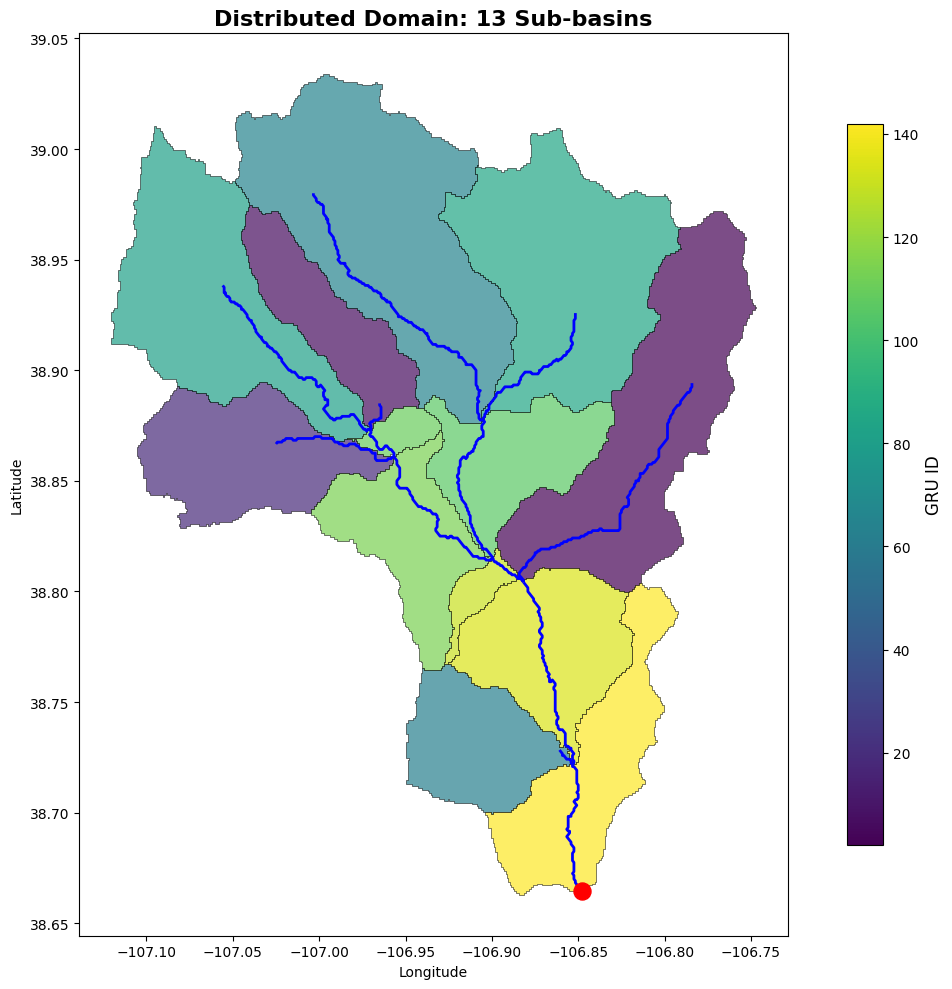

In [7]:
# Visualize the delineated domain with stream network
basin_files = list((project_dir / 'shapefiles' / 'river_basins').glob('*.shp'))
network_files = list((project_dir / 'shapefiles' / 'river_network').glob('*.shp'))
    
if basin_files and network_files:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Load data
    basins = gpd.read_file(basin_files[0])
    rivers = gpd.read_file(network_files[0])
    
    # Plot basins with different colors
    basins.plot(ax=ax, column='GRU_ID', cmap='viridis', 
               alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Plot river network
    rivers.plot(ax=ax, color='blue', linewidth=2)
    
    # Add pour point
    pour_point = gpd.read_file(pour_point_path)
    pour_point.plot(ax=ax, color='red', markersize=150, marker='o', zorder=5)
    
    ax.set_title(f'Distributed Domain: {len(basins)} Sub-basins', fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    # Add colorbar for GRU IDs
    sm = plt.cm.ScalarMappable(cmap='viridis', 
                               norm=plt.Normalize(vmin=basins['GRU_ID'].min(), 
                                                 vmax=basins['GRU_ID'].max()))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label('GRU ID', fontsize=12)
    
    plt.tight_layout()
    plt.show()

## Geospatial Domain Definition - Discretization

Now we'll create Hydrologic Response Units (HRUs) based on the Grouped Response Units (GRUs) we just created.

In [8]:
# Geospatial Domain Definition - Discretization

print(f"Creating HRUs based on GRUs...")
print(f"Method: {confluence.config['DOMAIN_DISCRETIZATION']}")
print("For this tutorial: 1 GRU = 1 HRU (simplest case)")

hru_path = confluence.managers['domain'].discretize_domain()

# Check the created HRU shapefile
catchment_path = project_dir / 'shapefiles' / 'catchment'
if catchment_path.exists():
    hru_files = list(catchment_path.glob('*.shp'))
    print(f"\n✓ Created HRU shapefiles: {len(hru_files)}")
    
    if hru_files:
        hru_gdf = gpd.read_file(hru_files[0])
        print(f"\nHRU Statistics:")
        print(f"Number of HRUs: {len(hru_gdf)}")
        print(f"Number of GRUs: {hru_gdf['GRU_ID'].nunique()}")
        print(f"Total area: {hru_gdf.geometry.area.sum() / 1e6:.2f} km²")
        
        # Show HRU distribution
        hru_counts = hru_gdf.groupby('GRU_ID').size()
        print(f"\nHRUs per GRU:")
        for gru_id, count in hru_counts.items():
            print(f"  GRU {gru_id}: {count} HRUs")

Creating HRUs based on GRUs...
Method: GRUs
For this tutorial: 1 GRU = 1 HRU (simplest case)
18:43:32 ● Discretizing domain using method: GRUs
18:43:32 ● Starting domain discretization using attributes: ['GRUs']

18:43:32 │ Step 1/2: Running single attribute discretization method
18:43:32 ● config domain name East_River_distributed
18:43:32 ● Calculating mean elevation for each HRU
18:43:32 ● DEM CRS: EPSG:4326
18:43:32 ● Shapefile CRS: EPSG:4326
18:43:32 ● CRS match - no reprojection needed
18:43:32 ● Successfully calculated elevation statistics for 13 HRUs
18:43:32 ● Calculated centroids in WGS84: lat range 38.719023 to 38.963130, lon range -107.060819 to -106.810220
18:43:32 ● GRUs saved as HRUs to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment/East_River_distributed_HRUs_GRUs.shp


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


18:43:33 ● HRU plot saved to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/plots/catchment/East_River_distributed_HRUs_as_GRUs.png

18:43:33 │ Step 2/2: Sorting catchment shape
18:43:33 ● Sorting catchment shape
18:43:33 ● Catchment shape sorted and saved to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment/East_River_distributed_HRUs_GRUs.shp
18:43:33 ● Domain discretization completed in 1.33 seconds
18:43:33 ● Domain discretization failed - no shapefile created

✓ Created HRU shapefiles: 1

HRU Statistics:
Number of HRUs: 13
Number of GRUs: 13
Total area: 0.00 km²

HRUs per GRU:
  GRU 2: 1 HRUs
  GRU 6: 1 HRUs
  GRU 18: 1 HRUs
  GRU 62: 1 HRUs
  GRU 65: 1 HRUs
  GRU 81: 1 HRUs
  GRU 85: 1 HRUs
  GRU 106: 1 HRUs
  GRU 110: 1 HRUs
  GRU 114: 1 HRUs
  GRU 130: 1 HRUs
  GRU 134: 1 HRUs
  GRU 142: 1 HRUs


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/tmp/ipykernel_337027/2650818361.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"Total area: {hru_gdf.geometry.area.sum() / 1e6:.2f} km²")


## Model Agnostic Data Processing - Observed Data

The observed streamflow data will be the same for both the lumped and distributed models since they use the same pour point.

In [9]:
# Model Agnostic Data Processing - Observed Data
print("Processing observed streamflow data...")
confluence.managers['data'].process_observed_data()

Processing observed streamflow data...
18:43:33 ● Processing observed data
18:43:33 ● Processing USGS streamflow data directly from API
18:43:33 ● Retrieving discharge data for station 09112500
18:43:33 ● Time period: 2000-01-02 to 2025-08-24
18:43:33 ● Converting from cfs to cms using factor: 0.0283168
18:43:33 ● Using formatted start date: 2000-01-02
18:43:33 ● Using formatted end date: 2025-08-24
18:43:33 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=09112500&format=rdb&parameterCd=00060&startDT=2000-01-02&endDT=2025-08-24


18:43:34 ● Using discharge column: 18852_00060_00003
18:43:34 ● Using datetime column: datetime
18:43:34 ● Dropping 24 rows with non-numeric discharge values
18:43:37 ● Processed streamflow data saved to: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/streamflow/preprocessed/East_River_distributed_streamflow_processed.csv
18:43:37 ● Total rows in processed data: 224785
18:43:37 ● Number of non-null values: 224211
18:43:37 ● Number of null values: 574
18:43:37 ● Successfully processed USGS data for station 09112500
18:43:37 ● Retrieved 9343 records from 2000-01-02 00:00:00 to 2025-08-24 00:00:00
18:43:37 ● Processing SNOTEL data
18:43:37 ● SNOTEL data processing is disabled in configuration
18:43:37 ● Processing FLUXNET data
18:43:37 ● FLUXNET data processing is disabled in configuration
18:43:37 ● Processing USGS groundwater level data
18:43:37 ● USGS groundwater data processing is disabled in configuration
18:43:37 ● Observed data processing completed suc

## Model Agnostic Data Processing - Preprocessing

In [10]:
# Model Agnostic Data Processing - Preprocessing
print("\nRunning model-agnostic preprocessing...")

confluence.managers['data'].run_model_agnostic_preprocessing()

print("\n✓ Model-agnostic preprocessing completed")


Running model-agnostic preprocessing...
18:43:37 ● Starting model-agnostic preprocessing
18:43:37 ● Running geospatial statistics
18:43:37 ● Starting geospatial statistics calculation
18:43:37 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
18:43:37 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
18:43:37 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
18:43:37 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
18:43:37 ● Running forcing resampling
18:43:37 ● Starting forcing data resampling process
18:43:37 ● Creating ERA5 shapefile
18:43:37 ● Forcing shapefile already exists: /sc

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


EASYMORE saved target shapefile for EASYMORE claculation as:
./East_River_distributed_ERA5_target_shapefile.shp


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


EASYMORE detects case 1 - regular lat/lon

...

EASYMORE detects that the variables from the netCDF files are identicalin dimensions of the variables and latitude and longitude
EASYMORE detects that all the variables have dimensions of:
['time', 'latitude', 'longitude']
EASYMORE detects that the longitude variables has dimensions of:
['longitude']
EASYMORE detects that the latitude variables has dimensions of:
['latitude']
--CREATING-REMAPPING-FILE--
Started at date and time 2025-08-25 19:18:42.538354
EASYMORE detects that target shapefile is in WGS84 (epsg:4326)
EASYMORE detects that the field for ID is provided in sink/target shapefile
EASYMORE detects that the field latitude is provided in sink/target shapefile
EASYMORE detects that the field longitude is provided in sink/target shapefile
it seems everything is OK with the sink/target shapefile; added to EASYMORE object target_shp_gpd


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


EASYMORE saved target shapefile for EASYMORE claculation as:
./East_River_distributed_ERA5_target_shapefile.shp
EASYMORE detects case 1 - regular lat/lon
./East_River_distributed_ERA5_source_shapefile.shp
EASYMORE created the shapefile from the netCDF file and saved it here:
EASMORE detects that target shapefile is inside the boundary of source netCDF file  and therefore correction for longitude values -180 to 180 or 0 to 360 is not performed even if  the correction_shp_lon flag is set to True [default is True]


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field GRU_area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 125306213.83317076 of field HRU_area of feature 4 not successfully written. Pos

Ended at date and time 2025-08-25 19:18:42.802816
It took 0.264462 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/merged_data/ERA5_merged_201910.nc to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/basin_averaged_data/East_River_distributed_ERA5_remapped_ERA5_merged_201910.nc 
Started at date and time 2025-08-25 19:18:26.155898 
Ended at date and time 2025-08-25 19:18:43.518962 
It took 17.363064 seconds to finish the remapping of variable(s) 
---------------------
---------------------
19:18:43 ● Worker 3: Successfully processed ERA5_merged_201910.nc in 17.81 seconds
Remapping /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/merged_data/ERA5_merged_201911.nc to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/basin_averaged_data/East_R

## Model-Specific Processing - Preprocessing

Now we prepare inputs specific to our chosen hydrological model (SUMMA in this case), set up for a distributed configuration.

In [6]:
# Model Specific Processing and Initialization

print(f"Preparing {confluence.config['HYDROLOGICAL_MODEL']} input files...")
print(f"Note: For distributed mode with {confluence.config['HYDROLOGICAL_MODEL']}, this includes generating:")
print(f"  - Model parameter files for each GRU")
print(f"  - Routing configuration for river network")

confluence.managers['model'].preprocess_models()

print("\n✓ Model-specific preprocessing completed")

Preparing SUMMA input files...
Note: For distributed mode with SUMMA, this includes generating:
  - Model parameter files for each GRU
  - Routing configuration for river network
14:59:31 ● Starting model-specific preprocessing
14:59:31 ● Processing model: SUMMA
14:59:31 ● Starting SUMMA spatial preprocessing
14:59:31 ● Starting memory-efficient temperature lapse rate and data step application
14:59:31 ● Loading topology data...
14:59:31 ● Loaded topology data: 26 rows, 0.18 MB


14:59:31 ● Found 360 forcing files to process
14:59:31 ● Pre-calculating lapse rate corrections...
14:59:31 ● Prepared lapse corrections for 13 HRUs
14:59:31 ● Processing files in batches of 100
15:00:19 ● Completed processing of 360 ERA5 forcing files with temperature lapsing
15:00:19 ● Copying SUMMA base settings
15:00:19 ● SUMMA base settings copied to /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/SUMMA
15:00:19 ● Creating SUMMA file manager
15:00:19 ● SUMMA file manager created at /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/SUMMA/fileManager.txt
15:00:19 ● Creating forcing file list
15:00:19 ● Found 404 ERA5 forcing files
15:00:19 ● Forcing file list created at /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/SUMMA/forcingFileList.txt with 404 files
15:00:19 ● Creating initial conditions (cold state) file
15:00:19 ● Creating initial conditions (cold state) file
15:00:19 ● Initial conditions file created

## Run the Distributed Model

Now we execute the SUMMA model in distributed mode with routing.

In [12]:
# Run the Distributed Model
print("Note: This will take longer than the lumped model due to multiple units.")

confluence.managers['model'].run_models()

print("\n✓ Model execution completed")

Note: This will take longer than the lumped model due to multiple units.
15:51:23 ● Starting model runs
15:51:23 ● Running model: SUMMA
15:51:23 ● Starting SUMMA run
16:15:08 ● SUMMA run completed successfully
16:15:08 ● Starting mizuRoute run
16:15:08 ● mizuRoute run failed with error: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/route_runoff /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/mizuRoute/mizuroute.control' returned non-zero exit status 20.
16:15:08 ● Error during SUMMA model run: Command '/home/dlhogan/tools/src/mizuRoute/route/bin/route_runoff /scratch/dlhogan/ess-project-data/domain_East_River_distributed/settings/mizuRoute/mizuroute.control' returned non-zero exit status 20.
16:15:08 ● Traceback (most recent call last):
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/model_manager.py", line 262, in run_models
    mizuroute_runner.run_mizuroute()
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhy

## Visualize Distributed Model Results

In [9]:
sim_path = project_dir / 'simulations' / confluence.config['EXPERIMENT_ID'] / 'SUMMA'
sim_files = list(sim_path.glob('*.nc'))

# Load simulation data
print(f"Loading simulation data from: {sim_files[0]}")
sim_data = xr.open_dataset(sim_files[0])
sim_data

Loading simulation data from: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/simulations/distributed_tutorial_run/SUMMA/distributed_tutorial_run_timestep.nc


<xarray.Dataset> Size: 53MB
Dimensions:              (time: 166535, hru: 13, gru: 13)
Coordinates:
  * time                 (time) datetime64[ns] 1MB 2000-01-02T00:59:59.999986...
  * hru                  (hru) int64 104B 2 6 18 62 65 ... 110 114 130 134 142
  * gru                  (gru) int64 104B 2 6 18 62 65 ... 110 114 130 134 142
Data variables:
    pptrate              (time, hru) float64 17MB ...
    airtemp              (time, hru) float64 17MB ...
    latitude             (hru) float64 104B ...
    longitude            (hru) float64 104B ...
    averageRoutedRunoff  (time, gru) float64 17MB ...
    hruId                (hru) int64 104B ...
    gruId                (gru) int64 104B ...
Attributes: (12/32)
    summaVersion:     undefined
    buildTime:        Tue Jul 29 10:44:47 PM UTC 2025
    gitBranch:        
    gitHash:          
    soilCatTbl:       ROSETTA
    vegeParTbl:       MODIFIED_IGBP_MODIS_NOAH
    ...               ...
    snowLayers:       CLM_2010
    compaction:       anderson
    thCondSnow:       jrdn1991
    thCondSoil:       funcSoilWet
    spatial_gw:       localColumn
    subRouting:       timeDlay

Loading simulation data from: /work/comphyd_lab/data/CONFLUENCE_data/domain_Bow_at_Banff_distributed/simulations/distributed_tutorial/mizuRoute/distributed_tutorial.h.2011-01-01-03600.nc
Loading observation data from: /work/comphyd_lab/data/CONFLUENCE_data/domain_Bow_at_Banff_distributed/observations/streamflow/preprocessed/Bow_at_Banff_distributed_streamflow_processed.csv
Observation period: 2011-01-01 00:00:00 to 2023-12-31 00:00:00
Using reach ID for outlet: 123
Common data period: 2011-02-01 00:00:00 to 2022-01-01 00:00:00
Performance metrics:
  - RMSE: 37.83 m³/s
  - NSE: 0.33
  - PBIAS: -25.29%
  - KGE: 0.46
Plot saved to: /work/comphyd_lab/data/CONFLUENCE_data/domain_Bow_at_Banff_distributed/plots/results/distributed_tutorial_streamflow_comparison.png


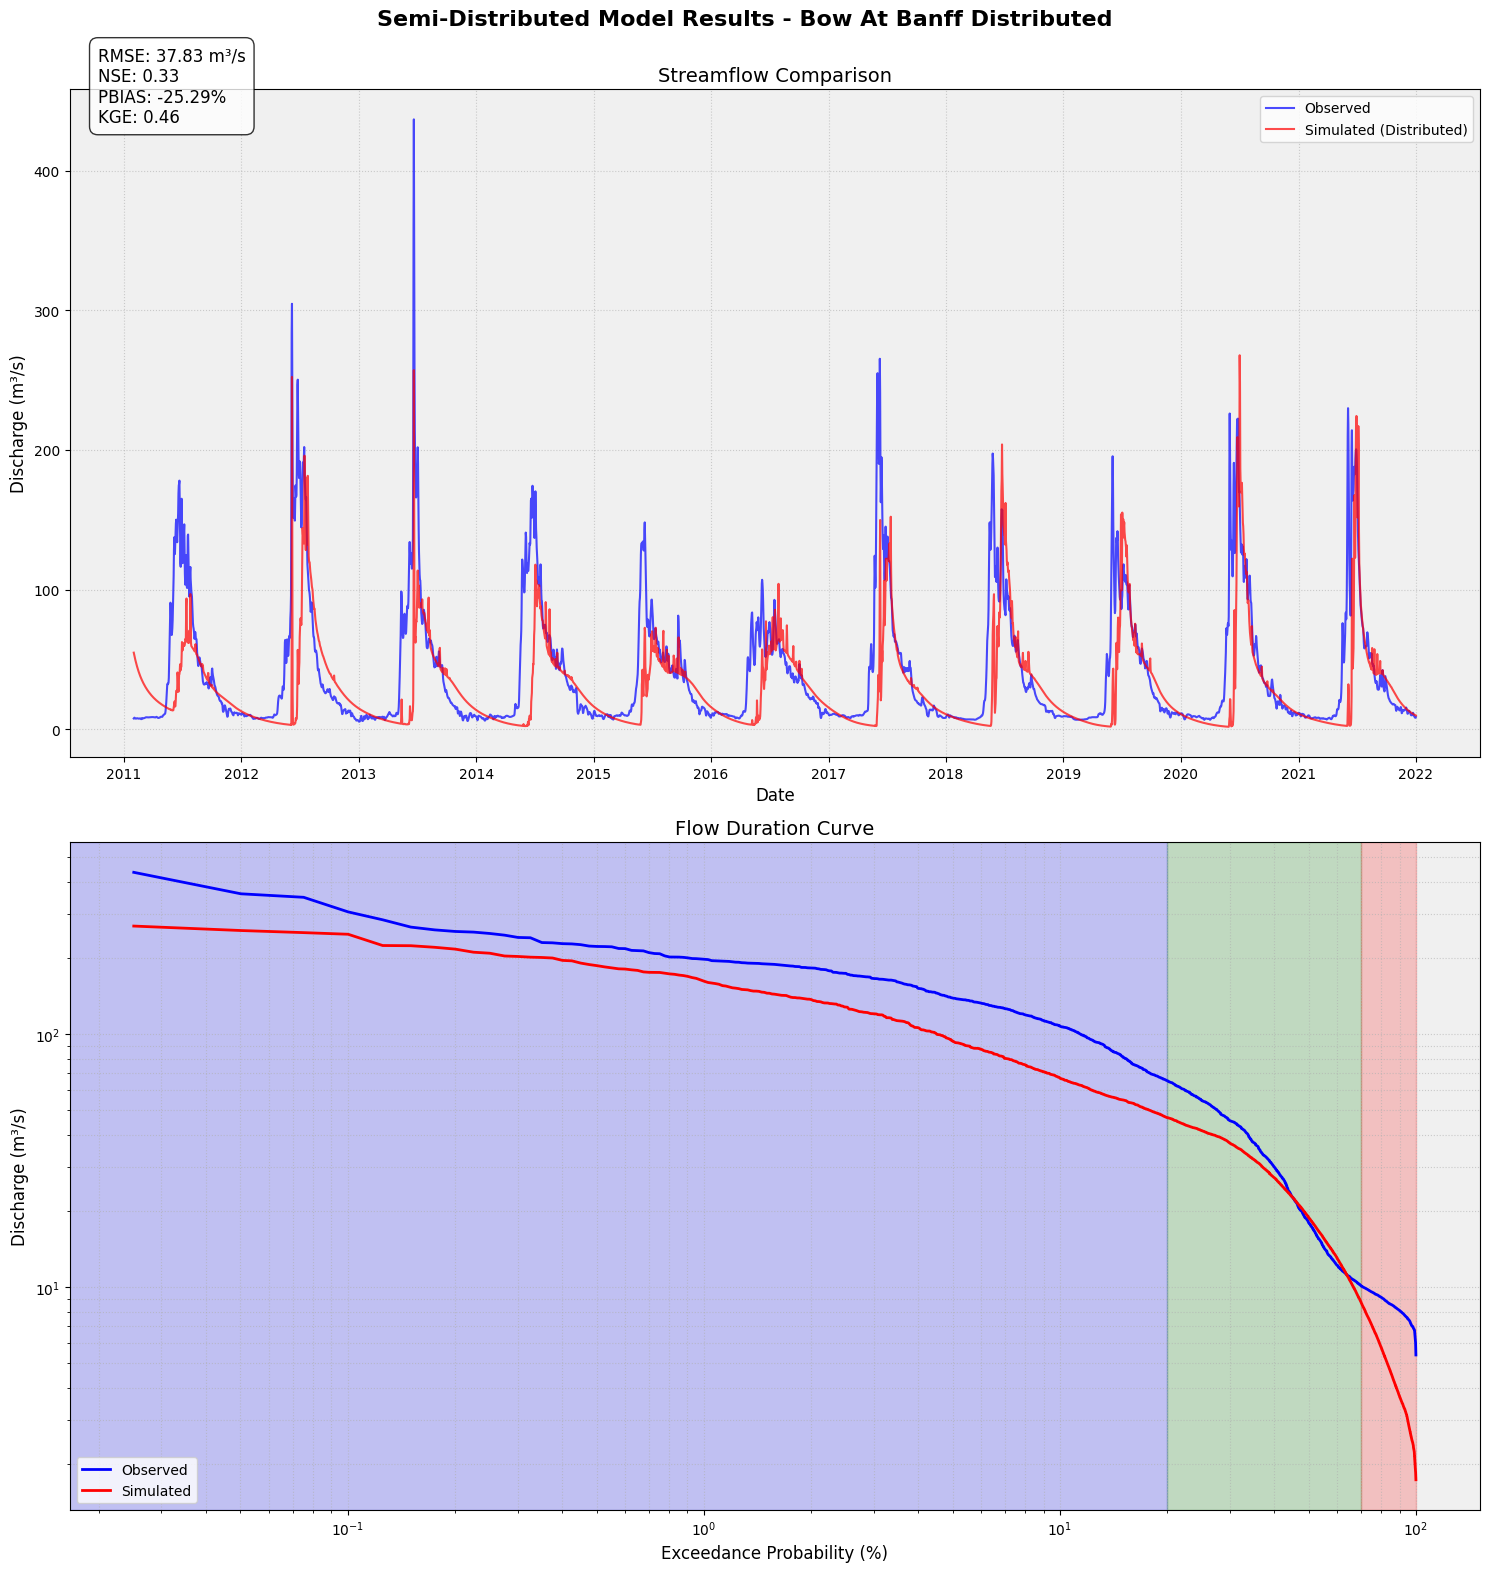

In [ ]:
# Visualize Observed vs. Simulated Streamflow

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import matplotlib.dates as mdates
from pathlib import Path

# Load and plot simulation results
sim_path = project_dir / 'simulations' / confluence.config['EXPERIMENT_ID'] / 'SUMMA'
sim_files = list(sim_path.glob('*.nc'))

# Load simulation data
print(f"Loading simulation data from: {sim_files[0]}")
sim_data = xr.open_dataset(sim_files[0])

# Load observation data
obs_path = project_dir / 'observations' / 'streamflow' / 'preprocessed' / f"{confluence.config['DOMAIN_NAME']}_streamflow_processed.csv"

if not obs_path.exists():
    print(f"Warning: Observation data not found at expected path: {obs_path}")
    print("Checking for alternative locations...")
    alt_obs_paths = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(
        f"domain_{config_dict['DOMAIN_NAME']}/observations/streamflow/preprocessed/*_streamflow_processed.csv"))
    
    if alt_obs_paths:
        obs_path = alt_obs_paths[0]
        print(f"Found alternative observation data at: {obs_path}")
    else:
        print("No observation data found. Only simulations will be displayed.")

if obs_path.exists():
    print(f"Loading observation data from: {obs_path}")
    obs_df = pd.read_csv(obs_path)
    obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])
    obs_df.set_index('datetime', inplace=True)
    print(f"Observation period: {obs_df.index.min()} to {obs_df.index.max()}")
else:
    obs_df = None
    
# Find the segment ID for the outlet
reach_id = int(confluence.config.get('SIM_REACH_ID', 0))
print(f"Using reach ID for outlet: {reach_id}")

# Find the index where reachID matches the target reach_id
segment_indices = np.where(sim_data.reachID.values == reach_id)[0]

if len(segment_indices) == 0:
    print(f"Error: Reach ID {reach_id} not found in simulation data")
    print(f"Available reach IDs: {sim_data.reachID.values}")
else:
    # Extract flow at the outlet segment using the index
    segment_index = segment_indices[0]
    sim_flow = sim_data.IRFroutedRunoff.isel(seg=segment_index).to_series()
    sim_df = pd.DataFrame(sim_flow)
    sim_df.columns = ['discharge_cms']

    # Determine common time period if observations exist
    if obs_df is not None:
        # Align to daily timestep for comparison
        obs_daily = obs_df.resample('D').mean()
        sim_daily = sim_df.resample('D').mean()
        
        # Find overlapping time period
        start_date = max(obs_daily.index.min(), sim_daily.index.min())
        end_date = min(obs_daily.index.max(), sim_daily.index.max())
        
        # Advance start date by 1 month to skip initial spinup
        start_date = start_date + pd.DateOffset(months=1)
        
        print(f"Common data period: {start_date} to {end_date}")
        
        # Filter to common period
        obs_period = obs_daily.loc[start_date:end_date]
        sim_period = sim_daily.loc[start_date:end_date]
        
        # Calculate performance metrics
        rmse = np.sqrt(((obs_period['discharge_cms'] - sim_period['discharge_cms'])**2).mean())
        
        # Calculate Nash-Sutcliffe Efficiency (NSE)
        mean_obs = obs_period['discharge_cms'].mean()
        numerator = ((obs_period['discharge_cms'] - sim_period['discharge_cms'])**2).sum()
        denominator = ((obs_period['discharge_cms'] - mean_obs)**2).sum()
        nse = 1 - (numerator / denominator)
        
        # Calculate Percent Bias (PBIAS)
        pbias = 100 * (sim_period['discharge_cms'].sum() - obs_period['discharge_cms'].sum()) / obs_period['discharge_cms'].sum()
        
        # Calculate Kling-Gupta Efficiency (KGE)
        r = obs_period['discharge_cms'].corr(sim_period['discharge_cms'])  # Correlation
        alpha = sim_period['discharge_cms'].std() / obs_period['discharge_cms'].std()  # Relative variability
        beta = sim_period['discharge_cms'].mean() / obs_period['discharge_cms'].mean()  # Bias ratio
        kge = 1 - ((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)**0.5
        
        print(f"Performance metrics:")
        print(f"  - RMSE: {rmse:.2f} m³/s")
        print(f"  - NSE: {nse:.2f}")
        print(f"  - PBIAS: {pbias:.2f}%")
        print(f"  - KGE: {kge:.2f}")
        
        # Create figure with two subplots for time series and flow duration curve
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
        fig.suptitle(f"Semi-Distributed Model Results - {confluence.config['DOMAIN_NAME'].replace('_', ' ').title()}", 
                     fontsize=16, fontweight='bold')
        
        # Plot time series
        ax1.plot(obs_period.index, obs_period['discharge_cms'], 
                 'b-', label='Observed', linewidth=1.5, alpha=0.7)
        ax1.plot(sim_period.index, sim_period['discharge_cms'], 
                 'r-', label='Simulated (Distributed)', linewidth=1.5, alpha=0.7)
            
        ax1.set_xlabel('Date', fontsize=12)
        ax1.set_ylabel('Discharge (m³/s)', fontsize=12)
        ax1.set_title('Streamflow Comparison', fontsize=14)
        ax1.legend(loc='upper right', fontsize=10)
        ax1.grid(True, linestyle=':', alpha=0.6)
        ax1.set_facecolor('#f0f0f0')
        
        # Format x-axis
        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # Add metrics as text
        ax1.text(0.02, 0.95, 
                 f"RMSE: {rmse:.2f} m³/s\nNSE: {nse:.2f}\nPBIAS: {pbias:.2f}%\nKGE: {kge:.2f}",
                 transform=ax1.transAxes, 
                 fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
        
        # Plot flow duration curve
        # Sort values in descending order
        obs_sorted = obs_period['discharge_cms'].sort_values(ascending=False)
        sim_sorted = sim_period['discharge_cms'].sort_values(ascending=False)
        
        # Calculate exceedance probabilities
        obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted)
        sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted)
        
        # Plot Flow Duration Curves
        ax2.loglog(obs_ranks * 100, obs_sorted, 'b-', label='Observed', linewidth=2)
        ax2.loglog(sim_ranks * 100, sim_sorted, 'r-', label='Simulated', linewidth=2)
        
        ax2.set_xlabel('Exceedance Probability (%)', fontsize=12)
        ax2.set_ylabel('Discharge (m³/s)', fontsize=12)
        ax2.set_title('Flow Duration Curve', fontsize=14)
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, which='both', linestyle=':', alpha=0.6)
        ax2.set_facecolor('#f0f0f0')
        
        # Add flow regime regions
        ax2.axvspan(0, 20, alpha=0.2, color='blue', label='High Flows')
        ax2.axvspan(20, 70, alpha=0.2, color='green', label='Medium Flows')
        ax2.axvspan(70, 100, alpha=0.2, color='red', label='Low Flows')
        
        # Save the plot to file
        plot_folder = project_dir / "plots" / "results"
        plot_folder.mkdir(parents=True, exist_ok=True)
        plot_filename = plot_folder / f"{confluence.config['EXPERIMENT_ID']}_streamflow_comparison.png"
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.93)
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {plot_filename}")
        
        plt.show()
    else:
        # If no observations, just plot simulation
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(sim_df.index, sim_df['discharge_cms'], 
                color='red', linewidth=1.5, label='Simulated (Distributed)')
        
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Discharge (m³/s)', fontsize=12)
        ax.set_title(f'Distributed Model Results - {confluence.config["DOMAIN_NAME"].replace("_", " ").title()}', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        
        plt.tight_layout()
        plt.show()

# Close the dataset
sim_data.close()

## 16. Optimization and Analysis (Optional)


In [ ]:
# Alternative: Run the complete workflow in one step
# (Uncomment to use this instead of the step-by-step approach)

# confluence.run_workflow()